In [4]:
import numpy as np
import pandas as pd
import multiprocessing as mp
import researchpy as rp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

In [5]:
def toDataFrame(glob_path, col_name, col_index, method):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d])

    df['method'] = method

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()

    result_df = pd.DataFrame()
    for col in df.columns:
        reshaped_data = df[col].values.reshape(-1, chunk_size)
        result_df[col] = reshaped_data.mean(axis=1)

    result_df.reset_index()

    result_df['epoch'] = result_df.index + 1
    result_df = result_df.melt(id_vars=['epoch'])

    return result_df

sns.set_style('whitegrid')



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9897  0.0007  0.0002     0.9892    0.9902


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9898  0.0007  0.0002     0.9893    0.9904


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  9.0  0.9883  0.0018  0.0006     0.9869    0.9897


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9882  0.0006  0.0002     0.9877    0.9886


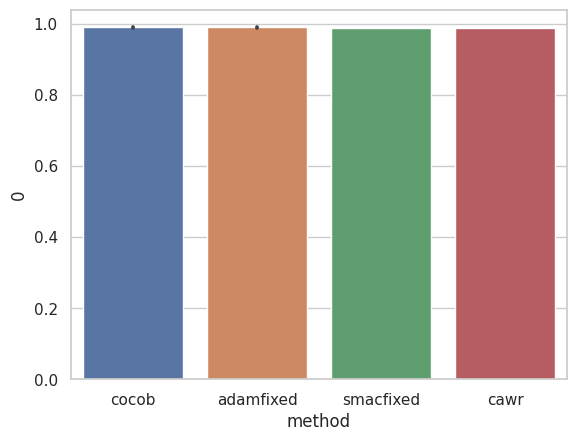

In [10]:
cocob_ta_mnist = toDataFrame('./results_cluster/results/COCOB_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_mnist = toDataFrame('./results_cluster/results/Adam_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_mnist = toDataFrame('./results_cluster/results/SMAC_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
cawr_ta_mnist = toDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([cocob_ta_mnist, adamfixed_ta_mnist, smacfixed_ta_mnist, cawr_ta_mnist])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(cocob_ta_mnist[0]))
print(rp.summary_cont(adamfixed_ta_mnist[0]))
print(rp.summary_cont(smacfixed_ta_mnist[0]))
print(rp.summary_cont(cawr_ta_mnist[0]))



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9154  0.0023  0.0007     0.9137     0.917


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9176  0.0022  0.0007      0.916    0.9192


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  9.0  0.9038  0.0127  0.0042      0.894    0.9136


   Variable     N    Mean     SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9076  0.002  0.0006     0.9061     0.909


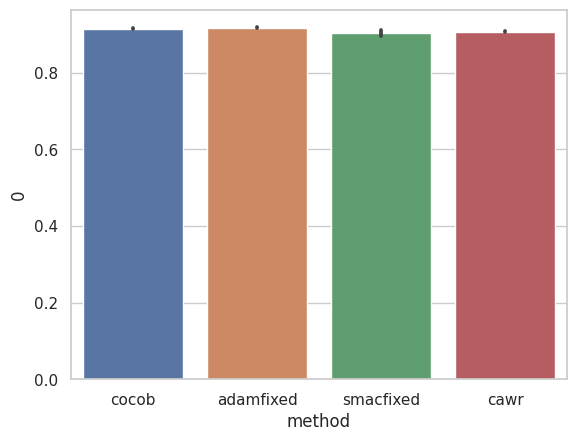

In [13]:
cocob_ta_fmnist = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_fmnist = toDataFrame('./results_cluster/results/Adam_fixed_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_fmnist = toDataFrame('./results_cluster/results/SMAC_fixed_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
cawr_ta_fmnist = toDataFrame('./results_cluster/results/CAWR_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([cocob_ta_fmnist, adamfixed_ta_fmnist, smacfixed_ta_fmnist, cawr_ta_fmnist])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(cocob_ta_fmnist[0]))
print(rp.summary_cont(adamfixed_ta_fmnist[0]))
print(rp.summary_cont(smacfixed_ta_fmnist[0]))
print(rp.summary_cont(cawr_ta_fmnist[0]))



   Variable     N    Mean     SD      SE  95% Conf.  Interval
0       0.0  10.0  0.7091  0.012  0.0038     0.7005    0.7176


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.7045  0.0113  0.0036     0.6964    0.7125


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.7603  0.0102  0.0032      0.753    0.7677


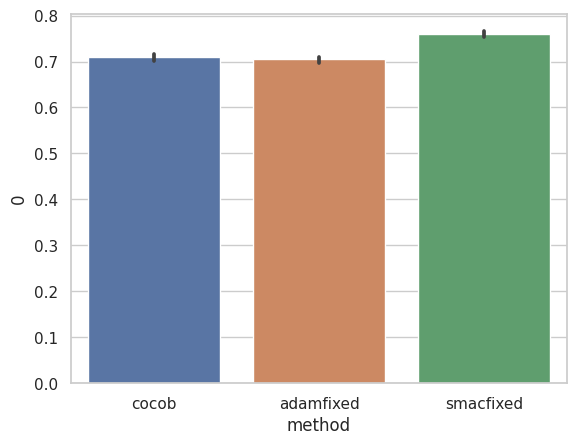

In [14]:
cocob_ta_cifar10 = toDataFrame('./results_cluster/results/COCOB_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_cifar10 = toDataFrame('./results_cluster/results/Adam_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_cifar10 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
#cawr_ta_mnist = toDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([cocob_ta_cifar10, adamfixed_ta_cifar10, smacfixed_ta_cifar10])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(cocob_ta_cifar10[0]))
print(rp.summary_cont(adamfixed_ta_cifar10[0]))
print(rp.summary_cont(smacfixed_ta_cifar10[0]))

Text(0, 0.5, 'Learning Rate')

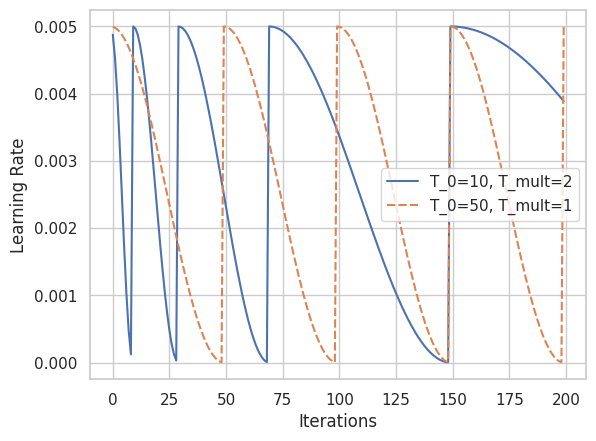

In [26]:
from dacbench_custom.cosine_annealing_agent import CosineAnnealingWRAgent as CAWR

def cawr_df(cawr):
    values = []
    for i in range(200):
        values.append(cawr.act())
    
    return pd.DataFrame(values)

cawr = CAWR(None, 10, 0, 0.005, 2)
cawr2 = CAWR(None, 50, 0, 0.005, 1)

df = pd.concat([cawr_df(cawr), cawr_df(cawr2)], axis=1)

df.columns = ['T_0=10, T_mult=2', 'T_0=50, T_mult=1']

sns.lineplot(data=df)
plt.xlabel('Iterations')
plt.ylabel('Learning Rate')